In [84]:
import pandas as pd
import numpy as np

In [85]:
import os

In [86]:
import zipfile

zip_file_path = '/content/train.csv.zip'
extract_dir = '/content/'

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

import pandas as pd
df = pd.read_csv(f'{extract_dir}train.csv')
print("train.csv loaded into DataFrame 'df'. First 5 rows:")
print(df.head())

train.csv loaded into DataFrame 'df'. First 5 rows:
   label  pixel0  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  \
0      1       0       0       0       0       0       0       0       0   
1      0       0       0       0       0       0       0       0       0   
2      1       0       0       0       0       0       0       0       0   
3      4       0       0       0       0       0       0       0       0   
4      0       0       0       0       0       0       0       0       0   

   pixel8  ...  pixel774  pixel775  pixel776  pixel777  pixel778  pixel779  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   
2       0  ...         0         0         0         0         0         0   
3       0  ...         0         0         0         0         0         0   
4       0  ...         0         0         0         0         0         0   

   pixel780  pixel781 

In [87]:
df.sample()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
18823,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [88]:
import matplotlib.pyplot as plt


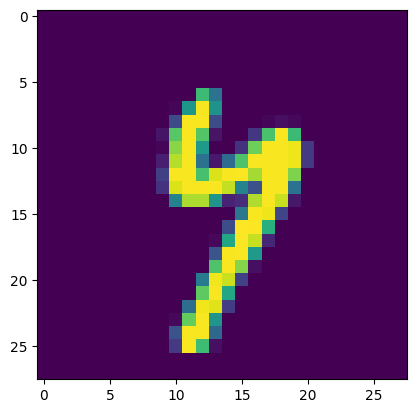

In [89]:
plt.imshow(df.iloc[23788, 1:].values.reshape(28,28))

In [90]:
x = df.iloc[:, 1:]
y = df['label']

In [91]:
from sklearn.model_selection import train_test_split

In [92]:
x_train, x_test,y_train, y_test = train_test_split(x,y, test_size=0.3, random_state=42)

In [93]:
from sklearn.neighbors import KNeighborsClassifier

In [94]:
knn = KNeighborsClassifier()

In [95]:
knn.fit(x_train, y_train)

KNeighborsClassifier()

In [96]:
import time
start = time.time()
y_pred = knn.predict(x_test)
print(time.time() - start)

22.30255150794983


In [97]:
from sklearn.metrics import accuracy_score

In [98]:
accuracy_score(y_test, y_pred)

0.9655555555555555

# **now with pca by first preprocessing the data by minimizing the numbe rof columns**

In [111]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [112]:
x_train = scaler.fit_transform(x_train)

In [113]:
x_test = scaler.transform(x_test)

In [114]:
#PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=200)

In [115]:
x_train_trf = pca.fit_transform(x_train)
x_test_trf = pca.transform(x_test)

In [116]:
x_train_trf.shape

(29400, 200)

In [117]:
x_train.shape

(29400, 784)

In [118]:
knn = KNeighborsClassifier()

In [119]:
knn.fit(x_train_trf, y_train)

KNeighborsClassifier()

In [120]:
y_pred = knn.predict(x_test_trf)

In [122]:
accuracy_score(y_test, y_pred)

0.9480952380952381

In [126]:
for i in range(1,785):
  pca = PCA(n_components=i)
  x_train_trf = pca.fit_transform(x_train)
  x_test_trf = pca.transform(x_test)
  knn = KNeighborsClassifier()
  knn.fit(x_train_trf, y_train)
  y_pred = knn.predict(x_test_trf)
  print(accuracy_score(y_test, y_pred), i)

0.25666666666666665 1
0.3291269841269841 2
0.5083333333333333 3
0.6637301587301587 4
0.7329365079365079 5
0.8206349206349206 6
0.8401587301587301 7
0.8695238095238095 8
0.8829365079365079 9
0.902063492063492 10
0.9103968253968254 11
0.9167460317460318 12
0.923968253968254 13
0.9314285714285714 14
0.9326190476190476 15
0.9334920634920635 16
0.9382539682539682 17
0.9383333333333334 18
0.9413492063492064 19
0.9407142857142857 20
0.9397619047619048 21
0.940952380952381 22
0.9434920634920635 23
0.9434920634920635 24
0.9450793650793651 25
0.9437301587301588 26
0.9447619047619048 27
0.9465873015873015 28
0.9478571428571428 29
0.9476190476190476 30
0.9488888888888889 31
0.9495238095238095 32
0.947936507936508 33
0.9494444444444444 34
0.9500793650793651 35
0.9507142857142857 36
0.9507142857142857 37
0.9511111111111111 38
0.9515873015873015 39
0.9514285714285714 40
0.9511904761904761 41
0.9507936507936507 42
0.9512698412698413 43
0.9512698412698413 44
0.9508730158730159 45
0.950952380952381 46
0

KeyboardInterrupt: 

In [128]:
pca = PCA(n_components=2)
x_train_trf = pca.fit_transform(x_train)
x_test_trf = pca.transform(x_test)
x_train_trf

array([[-6.50550591,  2.71986427],
       [-0.18900903, -2.65113705],
       [ 4.91167964,  8.57405008],
       ...,
       [ 2.08012018,  0.82281631],
       [ 0.97782002,  1.01727038],
       [17.74323303,  1.83850047]])

In [130]:
import plotly.express as px
y_train_trf = y_train.astype(str)
fig = px.scatter(x=x_train_trf[:,0],
                 y=x_train_trf[:,1],
                 color=y_train_trf,
                 color_discrete_sequence=px.colors.qualitative.G10
                )
fig.show()

In [132]:
# transforming in 3D
pca = PCA(n_components=3)
x_train_trf = pca.fit_transform(x_train)
x_test_trf = pca.transform(x_test)

In [134]:
x_train_trf

array([[-6.50550591,  2.71986427, -0.39181084],
       [-0.18900903, -2.65113705, -0.90468964],
       [ 4.91167964,  8.57405008, -0.74853538],
       ...,
       [ 2.08012018,  0.82281631, -0.73313352],
       [ 0.97782002,  1.01727038,  3.93831786],
       [17.74323303,  1.83850047, -4.94185759]])

In [135]:
import plotly.express as px
y_train_trf = y_train.astype(str)
fig = px.scatter_3d(df, x=x_train_trf[:,0], y=x_train_trf[:,1], z=x_train_trf[:,2],
              color=y_train_trf)
fig.update_layout(
    margin=dict(l=20, r=20, t=20, b=20),
    paper_bgcolor="LightSteelBlue",
)
fig.show()

In [136]:
pca.explained_variance_
# Eigen values


array([40.88572671, 29.24344599, 26.65306581])

In [137]:
pca.components_.shape
# Eigen vectors

(3, 784)

In [138]:
pca.explained_variance_ratio_

array([0.05848975, 0.04183469, 0.03812898])

In [139]:
pca = PCA(n_components=None)
x_train_trf = pca.fit_transform(x_train)
x_test_trf = pca.transform(x_test)

In [140]:
pca.explained_variance_.shape

(784,)

In [141]:
pca.components_.shape

(784, 784)

In [142]:
np.cumsum(pca.explained_variance_ratio_)

array([0.05848975, 0.10032445, 0.13845343, 0.16837346, 0.19440565,
       0.21708978, 0.23696127, 0.25468585, 0.27052881, 0.28497901,
       0.29871361, 0.31106466, 0.322657  , 0.33390419, 0.3445276 ,
       0.35482732, 0.36444872, 0.3739156 , 0.38309374, 0.39207922,
       0.40053907, 0.40880416, 0.41669842, 0.42431509, 0.43179871,
       0.43886265, 0.44588565, 0.45265202, 0.45913579, 0.46549502,
       0.4717047 , 0.47779166, 0.48368632, 0.48949707, 0.49525568,
       0.50081174, 0.50626205, 0.51159675, 0.51677315, 0.52174111,
       0.52667013, 0.53153464, 0.53620569, 0.54085527, 0.54545079,
       0.55000056, 0.55450634, 0.55892091, 0.56329359, 0.56761729,
       0.57187041, 0.57607204, 0.58021941, 0.58427558, 0.58831322,
       0.59224595, 0.59615753, 0.59998365, 0.60378401, 0.60750363,
       0.611202  , 0.61484538, 0.61844555, 0.62196812, 0.62541147,
       0.62882638, 0.63221453, 0.63558391, 0.63891834, 0.64220963,
       0.64547644, 0.64870651, 0.65192064, 0.65504799, 0.65816

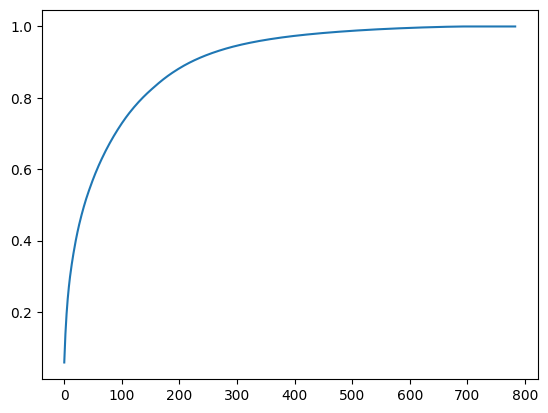

In [143]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))